# **ESERCIZIO 7.1**

Aggiorno il codice aggiungendo le tail corrections all'energia totale e alla pressione. Infatti, fino a questa esercitazione avevamo trascurato questi contributi, troncando il potenziale a una distanza finita r$_{cut}$. Quindi, le tail corrections non sono altro che correzioni secondarie a lungo raggio, che quantificano l'effetto delle interazioni a distanze maggiori di r$_{cut}$

In particolare, ho implementato le due formule viste a lezione in initialize_properties():

$$P_{\text{tail}} = \frac{32}{3}\pi \rho \left( \frac{1}{3 r_{\text{cut}}^{9}} - \frac{1}{2 r_{\text{cut}}^{3}} \right)$$

$$V_{\text{tail}} = \frac{8}{3}\pi \rho \left( \frac{1}{3 r_{\text{cut}}^{9}} - \frac{1}{r_{\text{cut}}^{3}} \right)$$

# **ESERCIZIO 7.2**

**OBIETTIVI**

In questo esercizio devo studiare il sistema di Lennard-Jones nella fase liquida utilizzando due metodi diversi: una simulazione Monte Carlo nel collettivo canonico (N,V,T) e una simulazione di Molecular Dynamics nel collettivo microcanonico (N,V,E). Le condizioni termodinamiche sono le stesse per entrambe le simulazioni e corrispondono a densità ridotta $\rho^*$=0.8, temperatura ridotta $T^*$=1.1 e raggio di cutoff $r_c^*$=2.5. Per la simulazione di dinamica molecolare il passo temporale richiesto è dt$^*$ = 0.001. Devo quindi eseguire due simulazioni separate e, infine, confrontarne il comportamento.

In particolare, nel caso di un collettivo microcanonico, il sistema è isolato e l'energia si conserva: la temperatura non è fissa ma fluttua, ed è definita dall'energia cinetica istantanea come $K=\frac{3}{2} N T$

Nel collettivo canonico, invece, è la temperatura del sistema ad essere mantenuta costante, e di conseguenza anche beta.

**RIEQUILIBRAZIONE**

Prima di eseguire entrambe le simulazioni devo equilibrare il sistema: in particolare, per MC imposto $T=1.1$ e $dt=0.1$, come suggerito a lezione, che mi permette di avere un valore di acceptance intorno al $50\%$.  Con questi parametri noto che l'energia potenziale si stabilizza attorno al valore $-5.46$, e che l'acceptance è attorno a $0.51$.

Per quanto riguarda la simulazione MD, invece, per raggiungere l'equilibrazione imposto un valore iniziale di $T=1.98$ e un $dt=0.001$ (come suggerito), che mi portano ad avere una temperatura che si stabilizza intorno a $1.1$, e un'energia potenziale attorno a $-5.47$. In particolare, leggo le configurazioni dal file $.fcc$.

**SIMULAZIONE**

Dopodichè, faccio partire la simulazione vera e propria, imponendo $restart=1$ per poter utilizzare le configurazioni finali "equilibrate". In particolare, simulo $500 000$ blocchi ciascuno da $1 step$, per poi stampare i valori istantanei di $U/N$ e calcolare autocorrelazione e incertezza statistica con Python.

Il primo studio richiesto riguarda la funzione di autocorrelazione. Lo scopo è capire per quanto tempo due misure successive restino correlate tra loro. Questa informazione è importante perché suggerisce quanto grandi debbano essere i blocchi nel metodo del data blocking.

Il secondo studio richiesto consiste nell’applicare la tecnica del data blocking variando la dimensione del blocco da $L=10$ fino a $L=5000$. Il dataset totale di lunghezza $500 000$ viene suddiviso in blocchi consecutivi di lunghezza $L$, ottenendo $N/L$ blocchi. Per ogni blocco si calcola la media di $U/N$, poi si usa la dispersione delle medie dei blocchi per stimare l’incertezza statistica sulla media complessiva.

**IMPLEMENTAZIONE FUNZIONE DI AUTOCORRELAZIONE:**  

  La funzione di autocorrelazione misura quanto un’osservabile $U(t)$ sia correlata con se stessa dopo un certo intervallo temporale, che prende il nome di lag $\tau$. Nel caso di questo esercizio, serve a quantificare quanto il valore dell’energia potenziale a un certo step sia ancora correlato a quello dopo $\tau$ passi della simulazione.

La funzione di autocorrelazione è definita come il valor medio del prodotto delle fluttuazioni del segnale $x(t)$ attorno al suo valor medio $\langle x\rangle$, normalizzato per la varianza; pertanto, l'ho implementata nel mio codice Python nel modo seguente:

$$C(\tau) = \frac{1}{\sigma^2}\,\bigl[\frac{1}{N-\tau}\sum_{t=0}^{N-\tau-1} \bigl(x(t) - \langle x \rangle\bigr)\bigl(x(t+\tau) - \langle x \rangle\bigr)\bigr]$$

Sto quindi stimando la correlazione media tra valori distanti $\tau$. In patricolare, la normalizzazione garantisce che $C(0)=1$, ovvero che all'istante iniziale le misure siano completamente correlate tra loro.

La funzione di autocorrelazione permette di stimare il tempo di correlazione del sistema $\tau_{corr}$, cioè il numero di passi necessari affinché le misure diventino indipendenti. Questo valore è fondamentale per scegliere correttamente la dimensione dei blocchi nel metodo del data blocking.

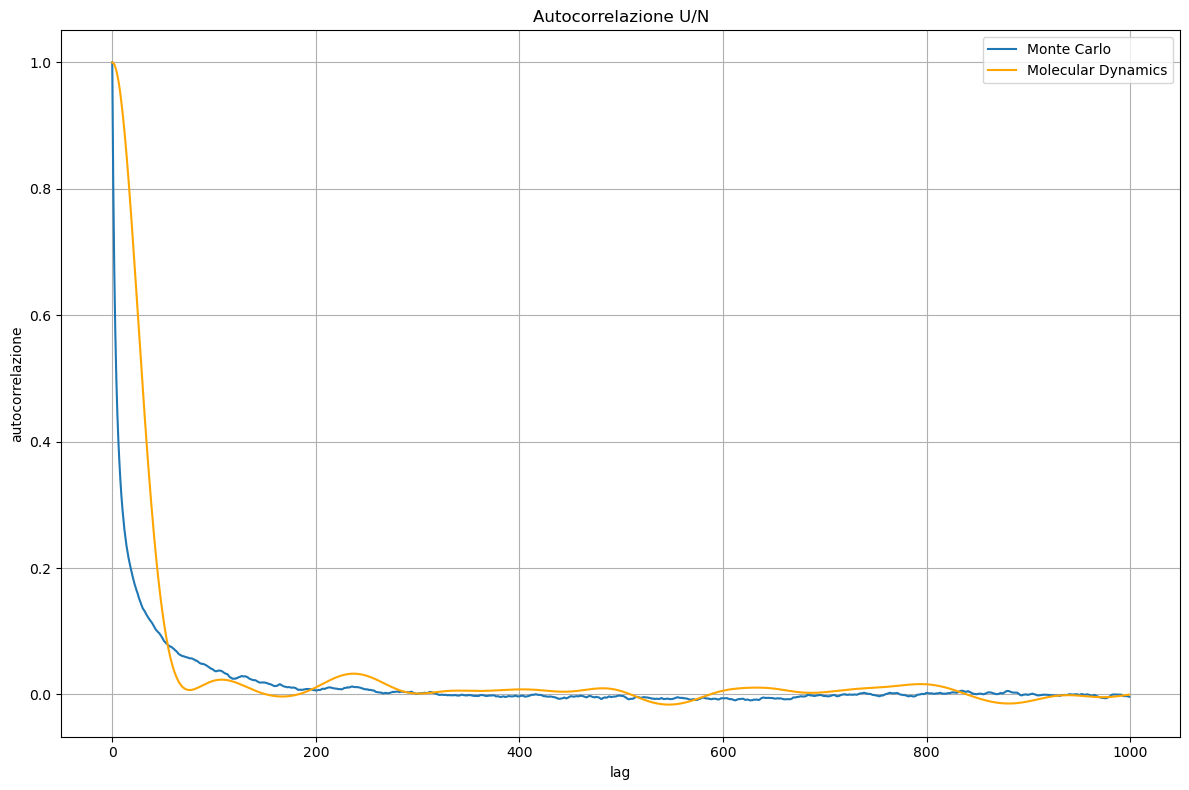

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#caricamento dati: potential energy istantanea
U_MC = np.loadtxt("NSL_SIMULATOR_7.1/RISULTATI/OUTPUT_MC/potential_energy.dat")
U_MD = np.loadtxt("NSL_SIMULATOR_7.1/RISULTATI/OUTPUT_MD/potential_energy.dat")


t_max = len(U_MC) #numero di punti totali usati nella simulazione

t_autocorr = np.arange(1000)   # lag fino a 1000


# FUNZIONE AUTOCORRELAZIONE
def autocorr(x, max_lag):
    x=x-np.mean(x)  #sottraendo a x il valor medio, centro la distribuzione dei miei dati attorno a zero: in questo modo, l'autocorrelazione misurerà solo le fluttuazioni
    norm=np.var(x)  #calcolo la varianza dei miei dati, che coincide con il denominatore della autocorrelazione
 
    N=len(x)      #salvo nella variabile N il numero totale di dati (500000)
    C=np.zeros(max_lag)  #creo un array di zeri, in cui andrò a memorizzare i valori dell'autocorrelazione per ogni lag

    for tau in range(max_lag): #ciclo su tutti i lag: ogni lag sarà un punto nel grafico
        C[tau]=np.mean(x[:N-tau]*x[tau:])/norm  #calcolo l'autocorrelazione: con x[:N-tau] prendo i valori fino a N - tau; con x[tau:] prendo i valori da tau in poi
                                                #moltiplico tra loro questi elementi per ogni tau, prendendo il valor medio della moltiplicazione
                                                #in particolare, * indica che sto facendo una moltiplicazione elemento per elemento, che mi permette di confrontare un x(t) con l'x(t+tau) corrispondente
    return C

# CALCOLO AUTOCORRELAZIONE
autocorr_MC = autocorr(U_MC, len(t_autocorr))
autocorr_MD = autocorr(U_MD, len(t_autocorr))


plt.figure(figsize=(12, 8))

plt.plot(t_autocorr, autocorr_MC, label='Monte Carlo')
plt.plot(t_autocorr, autocorr_MD, color='orange', label='Molecular Dynamics')

plt.title("Autocorrelazione U/N")
plt.xlabel("lag")
plt.ylabel("autocorrelazione")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

**COMMENTO AI RISULTATI OTTENUTI**

Analizzando il grafico notiamo che l'autocorrelazione tra le misure tende ad annullarsi attorno al lag $200$ per entrambe le configurazioni. Per garantire una stima affidabile dell’errore statistico nel metodo a blocchi, è necessario scegliere una dimensione dei blocchi significativamente maggiore del tempo di correlazione, in modo da ridurre le correlazioni tra blocchi consecutivi: per questo motivo mi aspetto di osservare la stabilizzazione dell’errore per valori di L dell’ordine di $2000$ step.

Si può inoltre notare che l'autocorrelazione decade molto più rapidamente nel caso MC rispetto al caso MD. Questa caratteristica è confermata dal grafico dell'incertezza statistica, riportato sotto, che mostra un'incertezza statistica minore per il metodo MC. La spiegazione a questo comportamento verrà pertanto fornita nella sezione sottostante.

**IMPLEMENTAZIONE METODO A BLOCCHI**

Ora devo graficare come varia l'errore statistico in funzione del numero di blocchi, ovvero del numero di step per blocchi. In particolare, come richiesto dall'esercizio, faccio variare la taglia L dei blocchi da 10 a 5000 step per blocchi, incrementando di 10 in 10 in valore degli step per blocco.

Per realizzare il grafico, prima di tutto implemento la funzione *errore_blocchi*, che permette di calcolare l'errore statistico tramite il metodo a blocchi. Dopodichè, faccio variare la taglia dei blocchi e per ciascun valore calcolo l'errore statistico con la funzione implementata. Infine, grafico l'andamento dell'errore in funzione di L per MC e per MD nello stesso grafico, in modo da poterli confrontare facilmente.

In particolare, dai risultati dell'autocorrelazione ottenuti al punto precedente, mi aspetto che l'errore si sia sicuramente stabilizzato attorno a L=2000.

Per completezza, ho riportato anche il plot dei dati istantanei di energia potenziale/particella per MD e per MC, che mostrano chiaramente come per entrambi i metodi i valori istantanei di questa grandezza oscillino attorno a uno stesso valor medio, indicando che:

1) il sistema è chiaramente equilibrato in entrambi i casi
2) i due metodi stanno descrivendo il sistema nello stesso stato termodinamico, quindi è sensato confrontarli 

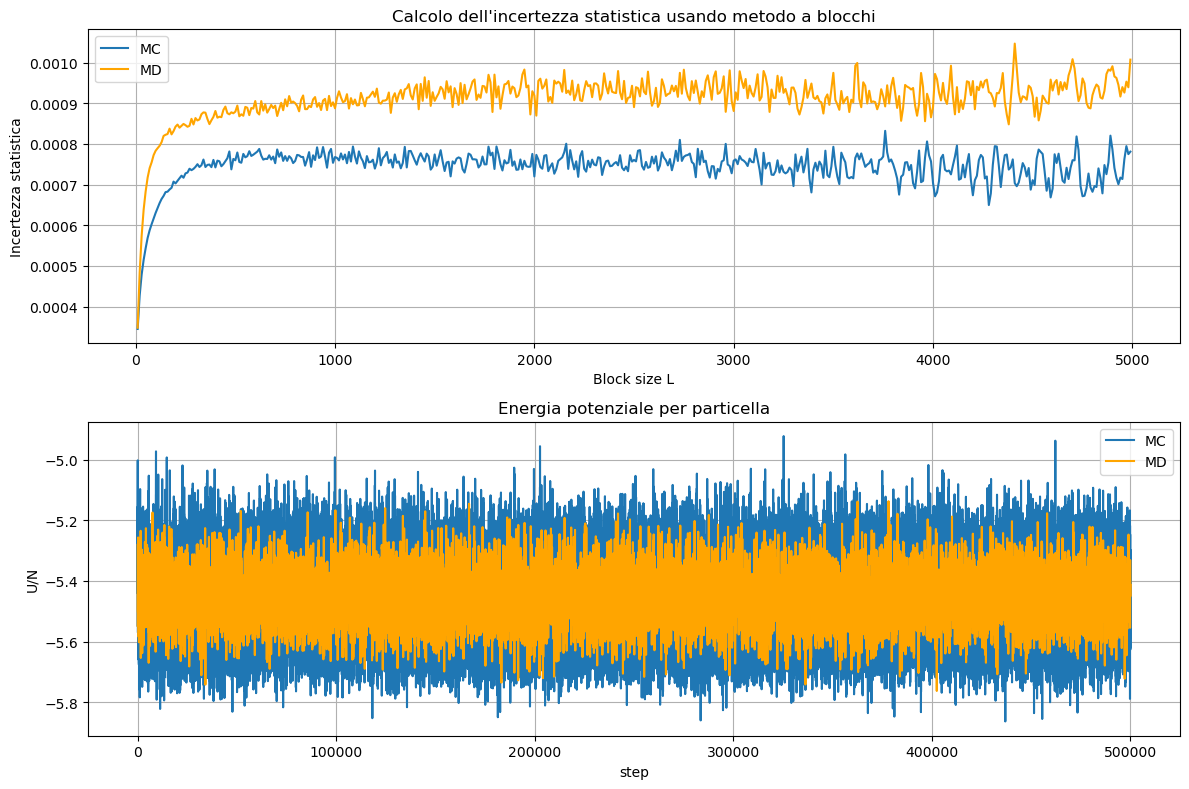

In [4]:
def errore_blocchi(data, L): #definisco la funzione per calcolare l'errore col metodo di data blocking (a seconda del numero di lanci per blocco L)

    M=len(data)              #numero totale di lanci: 500000
    N=M//L                 #numero blocchi=divisione intera

    if N < 2:
        return None  #se ho un blocco solo l'errore è 0

    trimmed=data[:N*L]  #prendo tutti i dati disponibili

    blocks=trimmed.reshape(N,L) #trasformo il mio vettore in una matrice, in cui le N righe rappresentano i blocchi e le L colonne le misure contenute in ciascun blocco

    block_av= np.mean(blocks,axis=1)  #calcolo la media per ogni blocco: axis=1 mi sta dicendo che devo mediare gli elementi di ogni riga

    mean=np.mean(block_av)   #calcolo la media delle medie dei blocchi
    mean2=np.mean(block_av**2)  #calcolo la media delle medie al quadrato

    error = np.sqrt((mean2 - mean**2) / N) #calcolo l'incertezza statistica

    return error


block_sizes = np.arange(10, 5000, 10) #voglio studiare come varia l'errore in base alla dimensione del blocco
                                      #sto creando una lista in cui parto da 10 step x blocco e arrivo a 5000, aumentando di 10 ogni volta il numeo di step

#creo array vuoti per salvare i risultati
error_MC = []
error_MD = []
L_val = []

for L in block_sizes:    #calcolo l'errore per ogni possibile dimensione del blocco

    err_mc = errore_blocchi(data_MC[:,1], L) #prendo i dati (1 colonna) della simulazione MC e ne caloclo l'errore con la funzione appena definita
    err_md = errore_blocchi(data_MD[:,1], L)

    error_MC.append(err_mc) #salvo l'errore associato a blocchi di dimensione L (append me lo inserisce nel primo posto disponbile)
    error_MD.append(err_md)
    L_val.append(L)  #salvo la dimensione del blocco corrispondente

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)

plt.plot(L_val, error_MC, label="MC")
plt.plot(L_val, error_MD, label="MD", color="orange")

plt.xlabel("Block size L")
plt.ylabel("Incertezza statistica")
plt.title("Calcolo dell'incertezza statistica usando metodo a blocchi")
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.subplot(2, 1, 2)

plt.plot(data_MC[:,0], U_MC, label="MC")
plt.plot(data_MC[:,0], U_MD, label="MD", color="orange")
plt.xlabel("step")
plt.ylabel("U/N")
plt.title("Energia potenziale per particella")
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.show()

**COMMENTO AI RISULTATI OTTENUTI**

Analizando il grafico relativo all'incertezza statistica notiamo che quando i blocchi sono troppo piccoli, cioè molto più brevi del tempo di correlazione, i dati all’interno di ciascun blocco non sono indipendenti e l’errore statistico viene sottostimato, come possiamo osservare nella prima parte del grafico. Per questo motivo, aumentando la dimensione del blocco, l’errore stimato tende inizialmente a crescere. Poi, continuando ad aumentare L, l’errore si stabilizza su un valore quasi costante. Questo appiattimento rappresenta la vera incertezza statistica della simulazione: in questo regime, infatti, ogni blocco è sufficientemente lungo e le medie di blocco diventano quasi indipendenti.

Inoltre, possiamo fare un'altra considerazione: anche se il numero totale di blocchi diminuisce all'aumentare di L, ogni blocco contiene più dati e quindi la sua media è determinata con maggiore precisione, e questo controbilancia la riduzione del numero di blocchi disponibili. Di conseguenza l’incertezza non continua a crescere, ma tende a stabilizzarsi attorno a un valore costante che rappresenta l’errore statistico. 

Inoltre, possiamo notare come nel caso di MD l'incertezza statistica risulti maggiore che in MC. Questo sta ad indicare che nelle condizioni considerate, i dati prodotti dal metodo MC risultano più efficienti dal punto di vista statistico, con configurazioni meno correlate tra loro. Questo è verosimilmente dovuto al fatto che MC e MD simulano il comportamento del sistema in esame in modi completamente differenti: MD si basa infatti sull'algoritmo Verlet, che calcola le diverse confiugrazioni del sistema sfruttandone la legge oraria tramite le forze e le velocità precedenti, e di conseguenza l'evoluzione è deterministica in quanto le configurazioni consecutive sono temporalmente correlate. Diversamente, MC basa l'evoluzione del sistema su spostamenti casuali, che non sono vincolati alla fisica del moto. Dunque, mi apsetto che i dati simulati con MD saranno più correlati di quelli simulati con MC: questo spiega come mai la correlazione decresce più rapidamente per MC, e come mai l'incertezza statistica risulta più bassa per MC.

# **ESERCIZIO 7.3**

Modifico il codice implementando il calcolo della funzione di distribuzione radiale $g(r)$, che misura la probabilità relativa di trovare una coppia di particelle a distanza r rispetto a un gas ideale alla stessa densità.

$$g(r) = \frac{1}{\rho N \Delta V(r)} \left\langle \sum_{i \neq j=1}^N \delta(r - (|\vec{r_i} - \vec{r_j}|)) \right\rangle$$

dove:

- $\vec{r_i} - \vec{r_j}$ indica il vettore distanza relativa tra le particelle i-esima e j-esima
- N è il numero di particelle totali del sistema
- $\rho$ è la densità del sistema
- $\Delta V$ è il volume del guscio sferico del bin: la normalizzazione tramite il volume del guscio sferico è necessaria dal momento che in uno spazio 3D le particelle possono disporsi in tutte le direzioni attorno a una particella di riferimento. Inoltre, il numero di configurazioni accessibili aumenta con il volume dello strato radiale considerato
  
**IMPLEMENTAZIONE**

Nel calcolo numerico, la funzione viene stimata tramite un istogramma delle distanze tra tutte le coppie di particelle:

$$g(r) = \frac{1}{\rho N} \frac{1}{\Delta V} \, \langle n(r) \rangle$$

dove:
- $n(r)$ è il numero di coppie che cadono nel bin [r, r+$\Delta$ r]
- $\Delta V=\frac{4}{3}\pi\cdot(bin_{up}^3-bin_{low}^3)$ è il volume del guscio sferico dei bin

Nel codice l'ho implementata in questo modo:
- considero tutte le coppie i<j, evitando doppi conteggi
- calcolo la distanza $r_{ij}$
- assegno la distanza al bin corrispondente
- per ciascuna coppia incremento l'istogramma di 2 per tenere conto del fatto che la coppia $(i,j)$ è equivalente alla coppia $(j,i)$: in questo modo il risultato è equivalente a scorrere tutte le coppie $i\neq j$ incrementando di 1

Infine applico la normalizzazione:

- divido per il volume del guscio sferico $\Delta V$
- divido per la densità $\rho$
- normalizzo sul numero di particelle

Nell'esercizio devo calcolare la g(r) sia per una simulazione Monte Carlo sia per una simulazione di dinamica molecolare.

Il confronto tra i due metodi permette di verificare la coerenza statistica delle configurazioni campionate e la corretta riproduzione delle proprietà strutturali del sistema.

# **ESERCIZIO 7.4**


Anche in questo esercizio devo fare due simulazioni separate, con MD e MC, dopo aver fatto in entrambi casi una equilibrazione iniziale. In particolare, come richiesto dall'esercizio, userò come parametri quelli della liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$). Inoltre, devo impostare come configurazione iniziale per la riequilibrazione la fcc, e come configurazioni iniziali per il restart quelle finali della simulazione di equilibrazione.


**IMPLEMENTAZIONE**

Calcolo la riequilibrazione in modo analogo al punto 2: per MC, imposto come suggerito a lezione $T=1.1$, $dt=0.1$, e verifico che l'acceptance si stabilisca attorno a $0.5$; per MD, devo impostare una T iniziale (in questo caso $1.98$) che mi permette di avere una T stabilizzata a $1.1$ al termine dell'equilibrazione. Verifico per entrambi i casi che l'energia potenziale sia anch'essa stabilizzata.

In particolare, ho usato 20 blocchi da 2000 step, come suggerito nelle slide, e ho "riciclato" la riequilibrazione del punto 2.

Infine, devo graficare $U/N$, pressione, $g(r)$ e devo confrontare i risultati ottenuti da MD e da MC.

Per quanto riguarda la pressione, è necessario distinguere tra simulazione MC e MD nel calcolo del contributo cinetico del teorema del viriale. In MD la temperatura istantanea viene ricavata dall’energia cinetica delle particelle, mentre in MC non vengono deifnite velocità (dal momento che l'algoritmo genera solo configurazioni spaziali) e quindi tale contributo non può essere valutato direttamente. In questo caso si utilizza la temperatura fissata per rappresentare il termine cinetico.

    if(_sim_type==1){
     _measurement(index_pressure) = _rho * _temp + (_ptail*_npart + 48.0*virial/3.0)/_volume;
    }else{
     _measurement(index_pressure) = _rho * (2.0/3.0) * kenergy_temp + (_ptail*_npart + 48.0*virial/3.0)/_volume;
    }

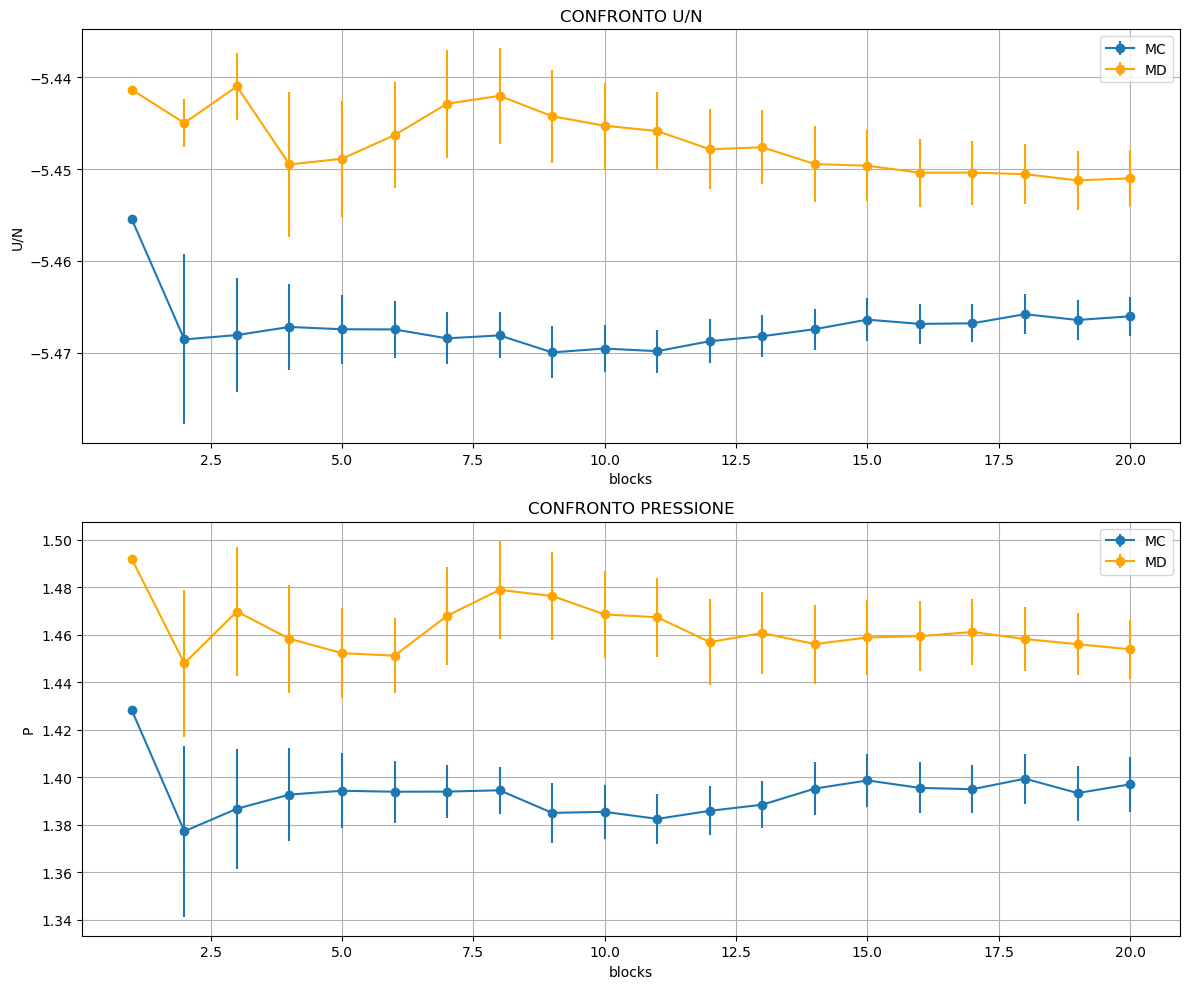

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#caricamento dati per stampare media + errore (metodo a blocchi)
GOFR_MC = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MC/gofr.dat")
P_MC    = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MC/pressure.dat")
U_MC    = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MC/potential_energy.dat")

GOFR_MD = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MD/gofr.dat")
P_MD    = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MD/pressure.dat")
U_MD    = np.loadtxt("NSL_SIMULATOR_7.3/RISULTATI/OUTPUT_MD/potential_energy.dat")


plt.figure(figsize=(12, 10))


plt.subplot(2, 1, 1)
plt.errorbar(U_MC[:,0], U_MC[:,2], yerr=U_MC[:,3], fmt='o-', label="MC") #stampo (numero blocco), potential energy media + errore
plt.title("CONFRONTO U/N")
plt.xlabel("blocks")
plt.ylabel("U/N")
plt.errorbar(U_MD[:,0], U_MD[:,2], yerr=U_MD[:,3], fmt='o-', color="orange", label="MD")
plt.xlabel("blocks")
plt.ylabel("U/N")
plt.legend()
plt.grid()


plt.subplot(2, 1, 2)
plt.errorbar(P_MC[:,0], P_MC[:,2], yerr=P_MC[:,3], fmt='o-', label="MC")
plt.title("CONFRONTO PRESSIONE")
plt.xlabel("blocks")
plt.ylabel("P")
plt.errorbar(P_MD[:,0], P_MD[:,2], yerr=P_MD[:,3], fmt='o-', color="orange", label="MD")
plt.xlabel("blocks")
plt.ylabel("P")
plt.legend()
plt.grid()



plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI OTTENUTI**

Osservando i grafici noto che dopo i primi blocchi le medie cumulative iniziano a stabilizzarsi attorno a un unico valore, indice che la riequilibrazione è avvenuta correttamente: se così non fosse, infatti, dovrei vedere una pendenza netta nei primi blocchi, indice che il sistema non si era ancora stabilizzato. In particolare, il fatto che i blocchi iniziali oscillino e non siano ancora stabilizzati risente del fatto che gli step compiuti, dunque i punti simulati, sono ancora troppo pochi per assestarsi sul valore corretto.

Un'altra caratteristica che emerge dai grafici è la discrepanza tra i valori di $U/N$ e di $p$ ottenuti tramite MC e quelli ottenuti tramite MD. Questa discrepanza potrebbe essere dovuta al fatto che in MC, essendo associato a un collettivo NVT, la temperatura è fissata dal collettivo canonico e imposta come parametro di simulazione, mentre in MD non è fissata dall'input ma è derivata da $K$. Infatti, in MD ho prima di tutto dovuto riequilibrare il sistema, impostando una temperatura di input in modo che successivamente il sistema si stabilizzasse attorno alla temperatura $1.1$. Ovviamente, però, il sistema non si è stabilizzato esattamente su una $T=1.1$, ma su un valore leggermente diverso, per via delle fluttuazioni statistiche: questo potrebbe avere influito sui valori di $U/N$ e di $p$ calcolati con MD, dal momento che la temperatura entra direttamente in gioco nel calcolo di entrambe queste grandezze. In particolare, analizzando le temperature medie ottenute nella prima parte di riequilibrazione, noto che esse sono sistematicamente maggiori di $1.1$, anche se in piccola misura. 

       BLOCK:   ACTUAL_T:     T_AVE:       ERROR:
           1      1.1548      1.1548           0
           2     1.10008     1.12744    0.019349
           3     1.10306     1.11931   0.0145057
           4     1.11273     1.11767   0.0109723
           5     1.10083      1.1143  0.00928043
           6     1.08162     1.10885  0.00919426
           7     1.11217     1.10933  0.00789303
           8     1.11877     1.11051  0.00699403
           9     1.09315     1.10858   0.0064774
          10     1.10678      1.1084  0.00583215


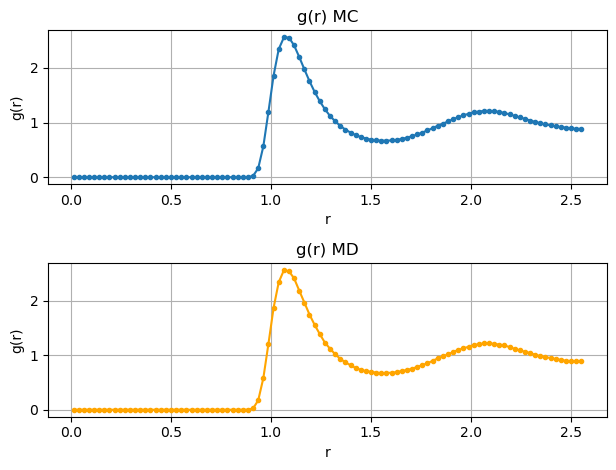

In [6]:
plt.subplot(2, 1, 1)
plt.errorbar(GOFR_MC[:,0], GOFR_MC[:,1], yerr=GOFR_MC[:,2], fmt='.-') #stampo: r, gofr media + errore
plt.title("g(r) MC")
plt.xlabel("r")
plt.ylabel("g(r)")
plt.grid()

plt.subplot(2, 1, 2)
plt.errorbar(GOFR_MD[:,0], GOFR_MD[:,1], yerr=GOFR_MD[:,2], fmt='.-', color="orange")
plt.title("g(r) MD")
plt.xlabel("r")
plt.ylabel("g(r)")
plt.grid()

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI OTTENUTI**

Dagli istogrammi della g(r) notiamo un picco pronunciato in corrispondenza di un valore di r finito, compreso tra 1.0 e 1.2. Questo picco mette in luce un aspetto importante: quando le particelle del liquido sono a brevi distanze le une dalle altre, tendono a disporsi a distanze preferenziali a causa delle forze interatomiche.

Inoltre, notiamo che per grandi distanze il grafico tende a stabilizzarsi verso 1: questo è coerente con quello che ci aspettiamo, ovvero che per grandi distanze il comportamento del nostro liquido si avvicina a quello di un gas ideale. Infatti, il fatto che la funzione di distribuzione radiale g(r) tenda a 1 per grandi distanze indica la perdita di correlazione spaziale tra le particelle, riportando il sistema al comportamento di un gas ideale.

Infine, notiamo che sia MC sia MD riproducono lo stesso grafico della g(r), nonostante siano basati su algoritmi differenti: entrambi riescono quindi a campionare in modo corretto la stessa struttura microscopica del fluido.